# Importation de librairies necessaire

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# models 
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

# Normalisation
from sklearn.preprocessing import StandardScaler

# separtion de train_set et test_set
from sklearn.model_selection import train_test_split

# Evaluation de models
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
  accuracy_score, 
  precision_score,
  recall_score,
  f1_score,
  confusion_matrix
  )

from sklearn.pipeline import Pipeline



# Chargement de dataset

In [2]:
data = pd.read_csv('../data/BankNoteAuthentication.csv')
data.head(10)

,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.80730,-0.44699,0
1,4.54590,8.1674,-2.45860,-1.46210,0
2,3.86600,-2.6383,1.92420,0.10645,0
3,3.45660,9.5228,-4.01120,-3.59440,0
4,0.32924,-4.4552,4.57180,-0.98880,0
5,4.36840,9.6718,-3.96060,-3.16250,0
6,3.59120,3.0129,0.72888,0.56421,0
7,2.09220,-6.8100,8.46360,-0.60216,0
8,3.20320,5.7588,-0.75345,-0.61251,0
9,1.53560,9.1772,-2.27180,-0.73535,0


## Exploration de données

In [3]:
print(data.shape)
print(data.info())
print(data.describe())
print(data.isnull().sum())
print(f"Doublons dans le dataset original : {data.duplicated().sum()}")


(1372, 5)
<class 'pandas.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   variance  1372 non-null   float64
 1   skewness  1372 non-null   float64
 2   curtosis  1372 non-null   float64
 3   entropy   1372 non-null   float64
 4   class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB
None
          variance     skewness     curtosis      entropy        class
count  1372.000000  1372.000000  1372.000000  1372.000000  1372.000000
mean      0.433735     1.922353     1.397627    -1.191657     0.444606
std       2.842763     5.869047     4.310030     2.101013     0.497103
min      -7.042100   -13.773100    -5.286100    -8.548200     0.000000
25%      -1.773000    -1.708200    -1.574975    -2.413450     0.000000
50%       0.496180     2.319650     0.616630    -0.586650     0.000000
75%       2.821475     6.814625     3.179250     0.394810     1.00000

In [4]:
# suppression de doublons
data = data.drop_duplicates().reset_index(drop=True)
print(f"Verification de doublons apres suppression : {data.duplicated().sum()}")

Verification de doublons apres suppression : 0


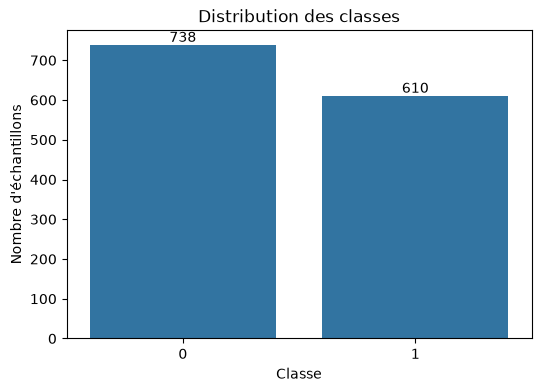

In [5]:
# visualisation de distribution
plt.figure(figsize=(6,4))

ax = sns.countplot(
    x='class',
    data=data
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution des classes")
plt.xlabel("Classe")
plt.ylabel("Nombre d'échantillons")

plt.show()

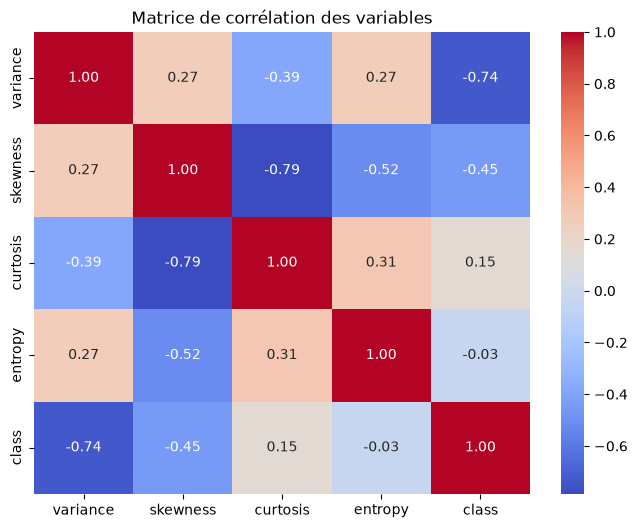

In [6]:
# Matrice de correlation
corr_matrix = data.corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matrice de corrélation des variables")
plt.show()

# Séparation de variable explicite  et cible

In [7]:
X = data.drop('class', axis=1)
y = data['class']

# Separation de données d'entrainement et les données de test

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

from sklearn.decomposition import PCA

# Réduction en 2 dimensions
pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

correlations = X_train.corrwith(y_train).sort_values(ascending=False)
print(correlations)


curtosis    0.158650
entropy    -0.035093
skewness   -0.453772
variance   -0.735338
dtype: float64


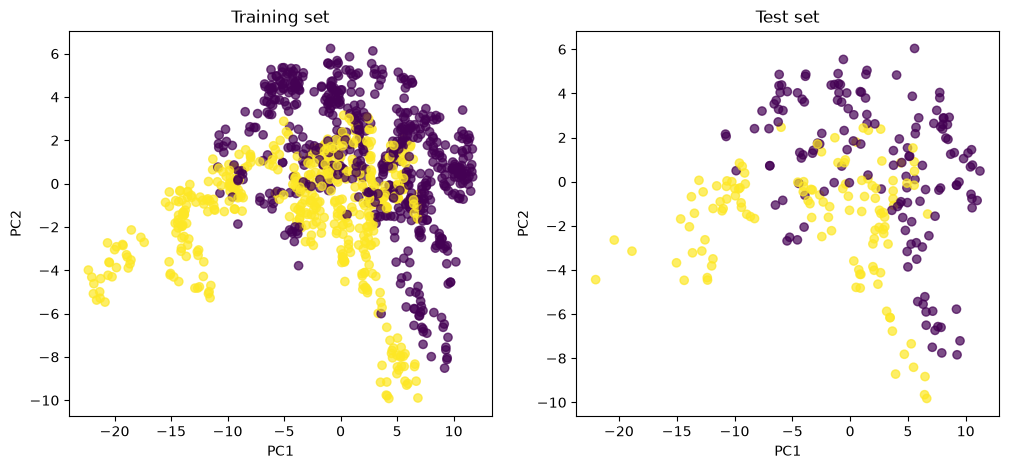

In [9]:
# graphiques des données de test
plt.figure(figsize=(12,5))

# Train
plt.subplot(1,2,1)

plt.scatter(
    X_train_pca[:,0],
    X_train_pca[:,1],
    c=y_train,
    alpha=0.7
)

plt.title("Training set")
plt.xlabel("PC1")
plt.ylabel("PC2")


# Test
plt.subplot(1,2,2)

plt.scatter(
    X_test_pca[:,0],
    X_test_pca[:,1],
    c=y_test,
    alpha=0.7
)

plt.title("Test set")
plt.xlabel("PC1")
plt.ylabel("PC2")


plt.show()

plt.show()

# Entrainnement de dataset avec plusieurs models differents

In [17]:
models = {

    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),

    "KNN": KNeighborsClassifier(),

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(random_state=42),

    "SVM": SVC(random_state=42),

    "Naive Bayes": GaussianNB(),

    "Gradient Boosting": GradientBoostingClassifier(random_state=42),

    "MLP": MLPClassifier(max_iter=1000, random_state=42)

}

need_scaling = [
    "Logistic Regression",
    "KNN",
    "SVM",
    "MLP"
]

# Grilles d'hyperparamètres
param_grids = {
  "Logistic Regression": {"model__C": [0.01, 0.1, 1, 10]},
  "KNN": {"model__n_neighbors": [3, 5, 7, 9]},
  "Decision Tree": {"model__max_depth": [3, 5, 10, None]},
  "Random Forest": {"model__n_estimators": [100, 200], "model__max_depth": [5, 10, None]},
  "SVM": {"model__C": [0.1, 1, 10], "model__kernel": ["linear", "rbf"]},
  "Naive Bayes": {},
  "Gradient Boosting": {"model__n_estimators": [100, 200], "model__learning_rate": [0.05, 0.1]},
  "MLP": {"model__hidden_layer_sizes": [(50,), (100,)], "model__alpha": [0.0001, 0.001]}
}

# Stratégie de validation croisée
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []
best_estimators = {}

for name, model in models.items():

  if name in need_scaling:
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])
  else:
    pipeline = Pipeline([
        ("model", model)
    ])
  grid = param_grids.get(name, {})
  search = GridSearchCV(
    estimator=pipeline,
    param_grid=grid,
    cv=cv,
    scoring="f1_weighted",   # à adapter : "accuracy", "f1_macro", etc.
    n_jobs=-1
  )

  search.fit(X_train, y_train)
  best_model = search.best_estimator_
  best_estimators[name] = best_model
  y_pred = best_model.predict(X_test)
  results.append({
      "Model": name,
      "Best Params": search.best_params_,
      "CV Score (f1_weighted)": search.best_score_,
      "Accuracy": accuracy_score(y_test, y_pred),
      "Precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
      "Recall": recall_score(y_test, y_pred, average="weighted", zero_division=0),
      "F1-score": f1_score(y_test, y_pred, average="weighted", zero_division=0)
  })

results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
results_df.drop(columns=['Best Params'])


,Model,CV Score (f1_weighted),Accuracy,Precision,Recall,F1-score
1,KNN,0.998145,1.000000,1.000000,1.000000,1.000000
3,Random Forest,0.991656,1.000000,1.000000,1.000000,1.000000
6,Gradient Boosting,0.993509,1.000000,1.000000,1.000000,1.000000
4,SVM,1.000000,1.000000,1.000000,1.000000,1.000000
7,MLP,0.997219,0.996296,0.996326,0.996296,0.996298
2,Decision Tree,0.979597,0.996296,0.996321,0.996296,0.996295
0,Logistic Regression,0.994434,0.985185,0.985655,0.985185,0.985203
5,Naive Bayes,0.840481,0.844444,0.846545,0.844444,0.844753


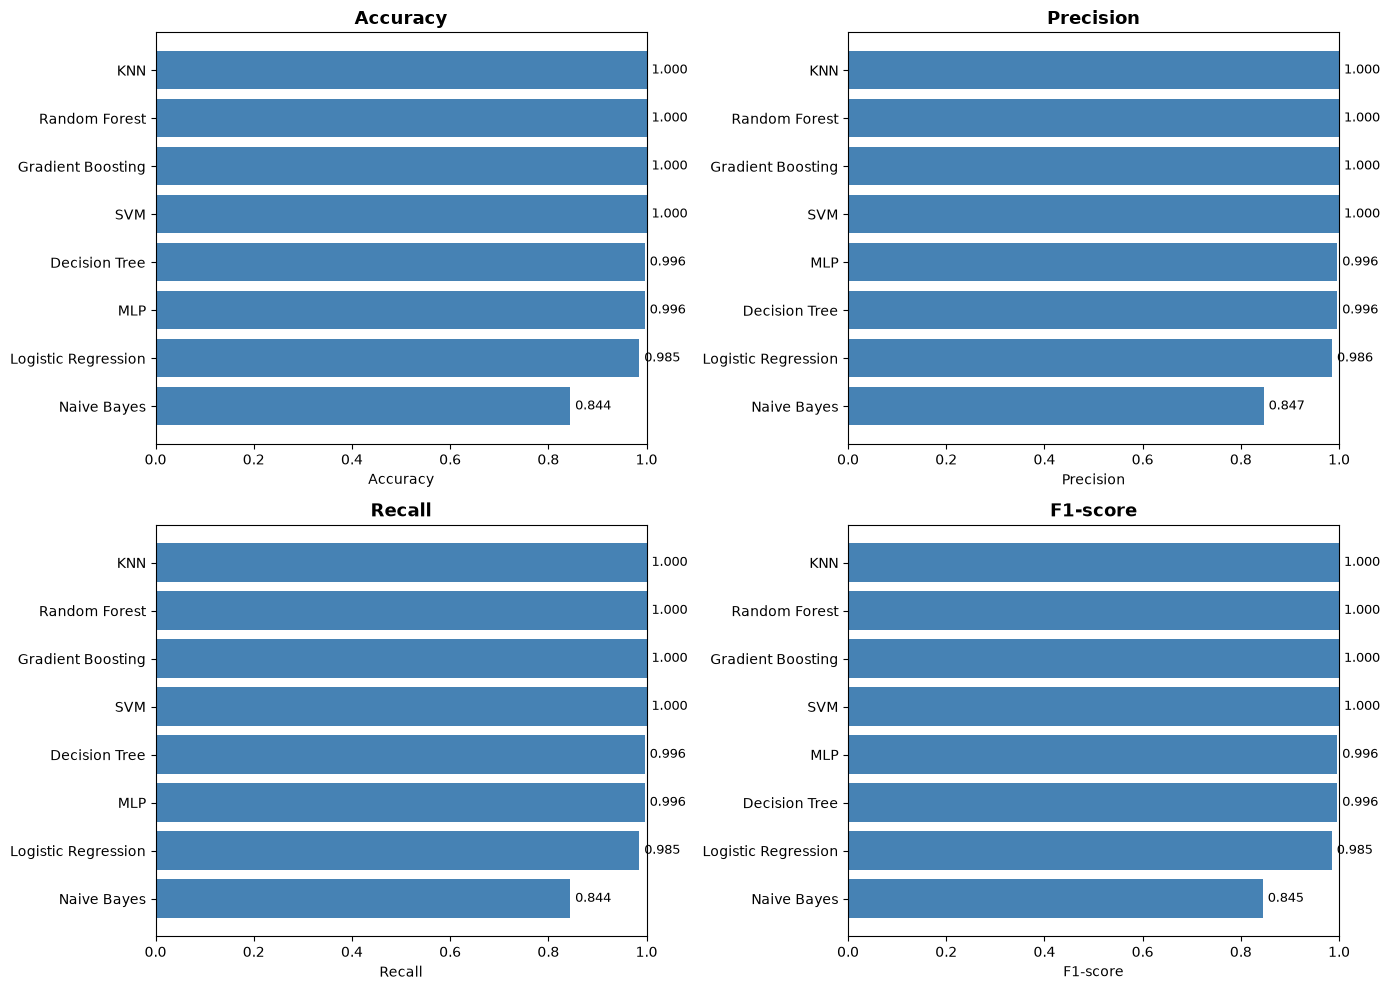

In [11]:

metrics = ["Accuracy", "Precision", "Recall", "F1-score"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    data = results_df.sort_values(by=metric, ascending=True)  # ascending pour un bel affichage horizontal
    
    axes[i].barh(data["Model"], data[metric], color="steelblue")
    axes[i].set_title(metric, fontsize=13, fontweight="bold")
    axes[i].set_xlim(0, 1)
    axes[i].set_xlabel(metric)
    
    # Afficher la valeur au bout de chaque barre
    for j, val in enumerate(data[metric]):
        axes[i].text(val + 0.01, j, f"{val:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("../docs/images/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Analyser en profondeur le modèle gagnant (KNN)

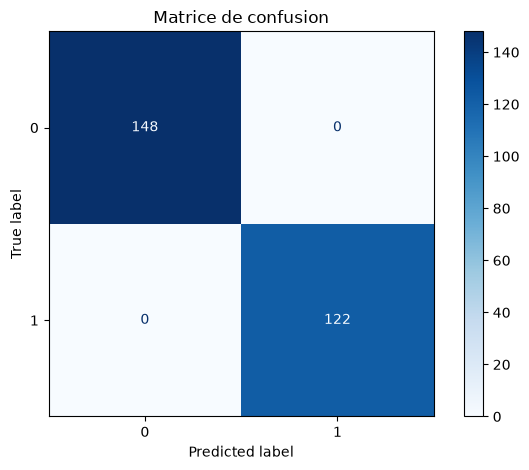

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       148
           1       1.00      1.00      1.00       122

    accuracy                           1.00       270
   macro avg       1.00      1.00      1.00       270
weighted avg       1.00      1.00      1.00       270



In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

best_knn = best_estimators["KNN"]
y_pred_knn = best_knn.predict(X_test)

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Matrice de confusion")
plt.tight_layout()
plt.savefig('../docs/images/confusion_matrix.png')
plt.show()

# Rapport détaillé par classe
print(classification_report(y_test, y_pred_knn))

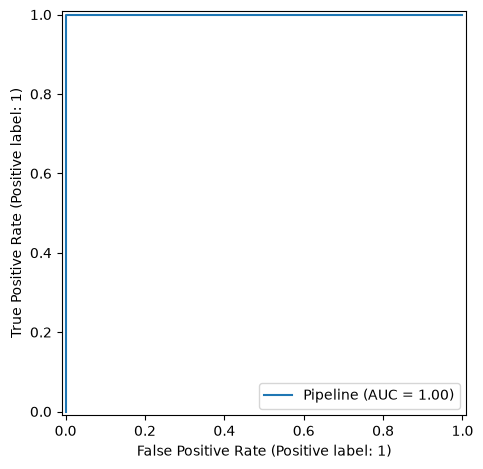

In [13]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(best_knn, X_test, y_test)
plt.tight_layout()
plt.savefig('../docs/images/roc_curve.png', dpi=150, bbox_inches="tight")
plt.show()

# Traçage de courbe d'apprentissage

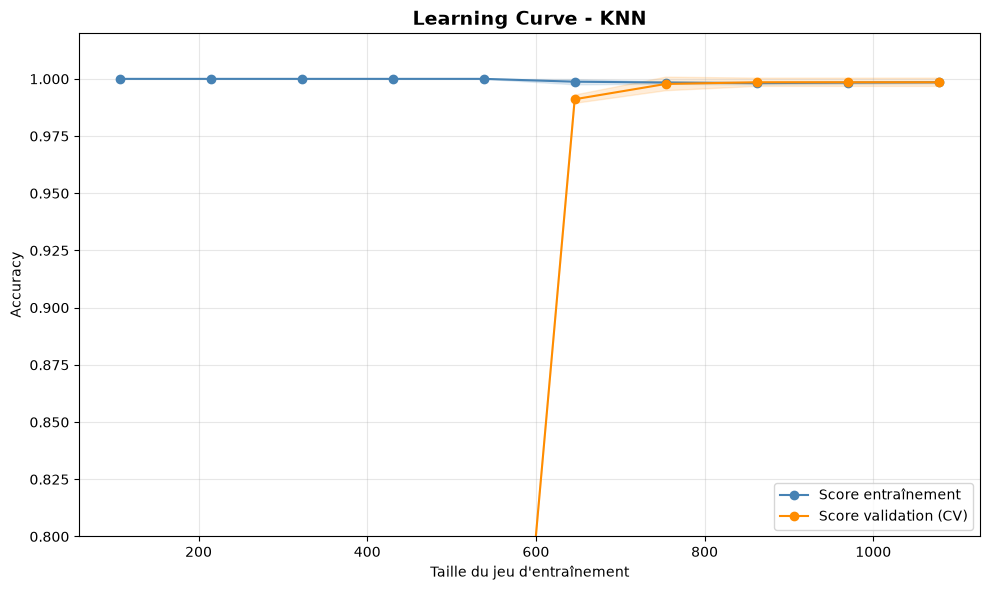

In [14]:
from sklearn.model_selection import learning_curve

# Utilise le pipeline complet (scaler + KNN) pour rester cohérent
best_knn = best_estimators["KNN"]

train_sizes, train_scores, test_scores = learning_curve(
    estimator=best_knn,
    X=X,               # dataset complet (X_train + X_test recombinés, ou X original nettoyé)
    y=y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 10),  # 10%, 20%, ..., 100% des données
    n_jobs=-1
)

# Moyennes et écarts-types
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_mean = test_scores.mean(axis=1)
test_std = test_scores.std(axis=1)

# Tracé
plt.figure(figsize=(10, 6))

plt.plot(train_sizes, train_mean, "o-", color="steelblue", label="Score entraînement")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                  alpha=0.15, color="steelblue")

plt.plot(train_sizes, test_mean, "o-", color="darkorange", label="Score validation (CV)")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std,
                  alpha=0.15, color="darkorange")

plt.title("Learning Curve - KNN", fontsize=14, fontweight="bold")
plt.xlabel("Taille du jeu d'entraînement")
plt.ylabel("Accuracy")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.ylim(0.8, 1.02)  # ajuste selon tes scores réels

plt.tight_layout()
plt.savefig("../docs/images/learning_curve_knn.png", dpi=150, bbox_inches="tight")
plt.show()

# Sauvegarder le model final

In [15]:
import joblib
joblib.dump(best_knn, '../models/best_model_knn.pkl')

['../models/best_model_knn.pkl']